# 04 · Analisis exploratorio (Parte 2)

| | |
|---|---|
| **Objetivo** | Caracterizar el fenomeno y producir insights accionables para operaciones |
| **Entradas** | `gold.trips_analytics`, `gold.agg_demanda_zona_hora` |
| **Salidas** | Visualizaciones e insights numerados. No produce tablas |
| **Depende de** | Notebook 03 |

**Proceso**
1. Caracterizar la distribucion del target y justificar su transformacion
2. Cuantificar el predictor dominante y la dispersion condicional
3. Medir efectos marginales y parciales de cada factor
4. Identificar regimenes de trayecto diferenciados
5. Analizar la estructura temporal y geografica de la demanda
6. Concluir con las features candidatas y persistir los hallazgos

**Nota metodologica.** Con 1,45 millones de observaciones las pruebas de
significancia clasicas pierden utilidad: a ese tamano muestral cualquier
diferencia, por trivial que sea, resulta estadisticamente significativa.
Todo el analisis se apoya por tanto en **tamanos de efecto**, que
cuantifican la magnitud, y no en valores p.

Los hallazgos se numeran como `INSIGHT-NN` para referenciarlos desde el
notebook 05 al comparar la importancia de variables con lo que el analisis
anticipo.

In [0]:
import os
import sys


# Localiza la raiz del repo subiendo hasta encontrar src/, en vez de fijar un
# numero de saltos. Asi el notebook funciona a cualquier profundidad.
def _preparar_path(marcador="src", max_niveles=10):
    ruta = os.getcwd()
    for _ in range(max_niveles):
        if os.path.isdir(os.path.join(ruta, marcador)):
            destino = os.path.join(ruta, marcador)
            if destino not in sys.path:
                sys.path.insert(0, destino)
            return destino
        padre = os.path.dirname(ruta)
        if padre == ruta:
            break
        ruta = padre
    raise RuntimeError(f"No se encontro la raiz del repo (carpeta con {marcador}/)")


_preparar_path()

import json

import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import functions as F

from nyc_taxi import config
from nyc_taxi.eda import spark_stats, stats

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

AZUL, NARANJA, GRIS = "#2E5A87", "#D97B29", "#8A8A8A"

RUTA_ARTEFACTOS = f"/Volumes/{config.CATALOGO}/{config.SCHEMA_GOLD}/artifacts"
spark.sql(f"CREATE VOLUME IF NOT EXISTS {config.CATALOGO}.{config.SCHEMA_GOLD}.artifacts")
os.makedirs(f"{RUTA_ARTEFACTOS}/figuras", exist_ok=True)


def guardar_figura(fig, nombre: str) -> None:
    """
    Persiste la figura en el Volume antes de mostrarla.

    El guardado ocurre en el momento de crear cada figura y no al final del
    notebook porque `plt.show()` cierra la figura en este entorno: recorrer
    `plt.get_fignums()` despues no encontraria ninguna.
    """
    fig.savefig(f"{RUTA_ARTEFACTOS}/figuras/{nombre}.png", dpi=150, bbox_inches="tight")

**Estrategia de computo.** Todos los estadisticos que se reportan
—tamanos de efecto, coeficientes, medidas de forma— se calculan **en Spark
sobre la poblacion completa**, mediante agregaciones que traen al driver
unicamente el resultado. Ningun numero de este analisis proviene de una
muestra.

La muestra aleatoria que se extrae a continuacion cumple una sola funcion:
alimentar los histogramas y diagramas de dispersion. Doscientos mil puntos
ya saturan visualmente cualquier figura, de modo que dibujar 1,45 millones
no anadiria informacion y si un coste considerable de memoria en el driver.

Las visualizaciones se construyen con matplotlib y no con `display()`
porque los graficos interactivos de la plataforma no se conservan al
exportar el notebook.

In [0]:
df = spark.table(config.TBL_ANALYTICS)
agg = spark.table(config.TBL_AGG_DEMANDA)

N_MUESTRA = 200_000
muestra = (
    df.select("trip_duration", "distancia_haversine_km", "distancia_manhattan_km",
              "bearing_deg", "pickup_hour", "pickup_dayofweek", "pickup_month",
              "is_weekend", "pickup_cluster", "dropoff_cluster", "velocidad_kmh",
              "pickup_latitude", "pickup_longitude", "dropoff_latitude",
              "dropoff_longitude", "split_flag", "es_aeropuerto")
    .sample(fraction=N_MUESTRA / df.count(), seed=config.SEMILLA)
    .toPandas()
)

print(f"Poblacion : {df.count():,} viajes")
print(f"Muestra   : {len(muestra):,} viajes")

Poblacion : 1,455,526 viajes
Muestra   : 199,998 viajes


## 1. Caracterizacion del target

In [0]:
# Estadisticos de forma sobre la poblacion completa (1,45 millones de filas).
forma = df.select(
    (F.avg("trip_duration") / 60).alias("media_min"),
    (F.expr("percentile_approx(trip_duration, 0.5)") / 60).alias("mediana_min"),
    (F.expr("percentile_approx(trip_duration, 0.9)") / 60).alias("p90_min"),
    F.skewness("trip_duration").alias("asimetria"),
    F.kurtosis("trip_duration").alias("curtosis"),
    F.skewness(F.log1p("trip_duration")).alias("asimetria_log"),
    F.kurtosis(F.log1p("trip_duration")).alias("curtosis_log"),
).first().asDict()

resumen = {k: float(v) for k, v in forma.items()}
for k, v in resumen.items():
    print(f"  {k:<16} {v:>8.2f}")

# La muestra se usa unicamente para dibujar.
dur = muestra.trip_duration.tolist()
log_dur = np.log1p(muestra.trip_duration).tolist()

  media_min           13.94
  mediana_min         11.02
  p90_min             27.07
  asimetria            2.58
  curtosis            17.03
  asimetria_log       -0.63
  curtosis_log         2.36


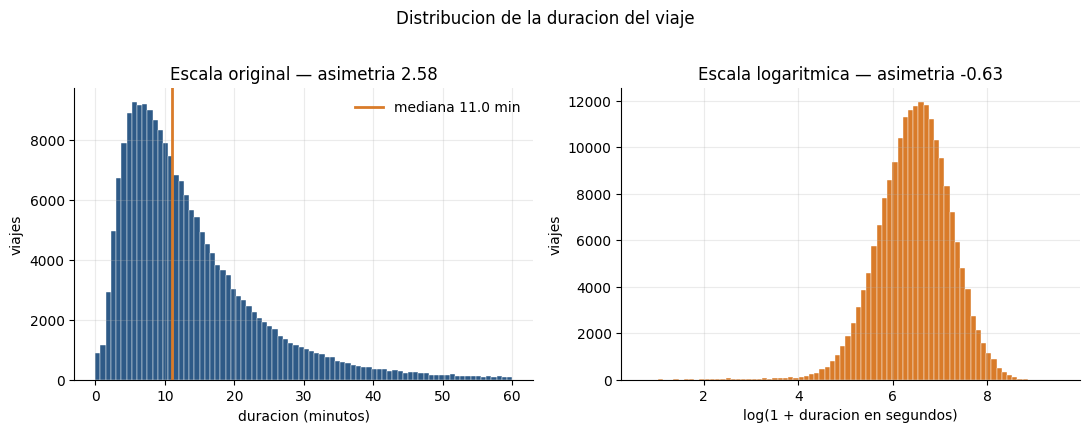

In [0]:
fig, ax = plt.subplots(1, 2)
ax[0].hist(np.array(dur) / 60, bins=80, range=(0, 60), color=AZUL, edgecolor="white", linewidth=0.3)
ax[0].axvline(np.median(dur) / 60, color=NARANJA, lw=2, label=f"mediana {np.median(dur)/60:.1f} min")
ax[0].set(xlabel="duracion (minutos)", ylabel="viajes",
          title=f"Escala original — asimetria {resumen['asimetria']:.2f}")
ax[0].legend(frameon=False)

ax[1].hist(log_dur, bins=80, color=NARANJA, edgecolor="white", linewidth=0.3)
ax[1].set(xlabel="log(1 + duracion en segundos)", ylabel="viajes",
          title=f"Escala logaritmica — asimetria {resumen['asimetria_log']:.2f}")

fig.suptitle("Distribucion de la duracion del viaje", y=1.02, fontsize=12)
plt.tight_layout()
guardar_figura(fig, "01_distribucion_target")
plt.show()

### INSIGHT-01 · El target exige transformacion logaritmica

La distribucion original presenta una asimetria cercana a 2,6 y una
curtosis en exceso superior a 15: cola derecha muy pesada. La media (13,9
minutos) supera a la mediana (11,0) en mas de un 25 %, senal de que unos
pocos trayectos largos desplazan el promedio.

Aplicar el logaritmo deja la asimetria en torno a −0,6 y la curtosis cerca
de 2, valores ya manejables.

**Consecuencia para el modelado:** entrenar sobre la escala original haria
que el error cuadratico quedara dominado por los trayectos extremos, de
modo que el modelo optimizaria el caso raro a costa del habitual.
Adicionalmente, la metrica oficial de la competencia es logaritmica, por lo
que la transformacion alinea el entrenamiento con el criterio de
evaluacion.

**Consecuencia para el negocio:** el indicador que debe comunicarse a
operaciones es la mediana, no el promedio. Reportar 13,9 minutos como
"viaje tipico" sobreestima el trayecto real de la mayoria de usuarios.

## 2. El predictor dominante y la dispersion condicional

In [0]:
# Regresion ajustada sobre la poblacion completa, no sobre la muestra.
df_log = (
    df.withColumn("log_dur", F.log1p("trip_duration"))
      .withColumn("log_dist", F.log1p("distancia_haversine_km"))
)
df_res, ajuste = spark_stats.agregar_residuos(df_log, "log_dist", "log_dur")
r2_dist = ajuste["r2"]
print(f"R2 de la distancia como unico predictor: {r2_dist:.4f}  "
      f"(sobre {df.count():,} viajes)")

x_log_dist = np.log1p(muestra.distancia_haversine_km).tolist()

tramos = [(0, 1), (1, 2), (2, 3), (3, 5), (5, 8), (8, 12), (12, 20), (20, 100)]
filas = []
for lo, hi in tramos:
    sel = muestra[(muestra.distancia_haversine_km > lo) & (muestra.distancia_haversine_km <= hi)]
    if len(sel) < 100:
        continue
    d = stats.dispersion_por_tramo(sel.trip_duration.tolist())
    filas.append({
        "tramo": f"{lo}-{hi} km", "n": len(sel),
        "p10": d["p10"] / 60, "p50": d["p50"] / 60, "p90": d["p90"] / 60,
        "ancho": d["ancho_p90_p10"] / 60, "razon": d["razon_p90_p10"],
    })

print(f"\n{'tramo':<12}{'n':>8}{'p10':>8}{'p50':>8}{'p90':>8}{'ancho':>8}{'razon':>8}")
for f in filas:
    print(f"{f['tramo']:<12}{f['n']:>8,}{f['p10']:>8.1f}{f['p50']:>8.1f}"
          f"{f['p90']:>8.1f}{f['ancho']:>8.1f}{f['razon']:>8.2f}")

R2 de la distancia como unico predictor: 0.5926  (sobre 1,455,526 viajes)

tramo              n     p10     p50     p90   ancho   razon
0-1 km        33,061     2.0     4.5     9.5     7.5    4.79
1-2 km        62,159     4.3     7.9    14.6    10.3    3.39
2-3 km        36,163     7.1    11.8    19.9    12.8    2.81
3-5 km        31,952     9.7    15.8    26.1    16.4    2.70
5-8 km        17,183    13.4    20.9    33.0    19.5    2.46
8-12 km       10,052    17.2    26.7    44.0    26.8    2.56
12-20 km       5,424    22.0    34.1    56.1    34.1    2.55
20-100 km      3,225    29.7    45.3    70.6    41.0    2.38


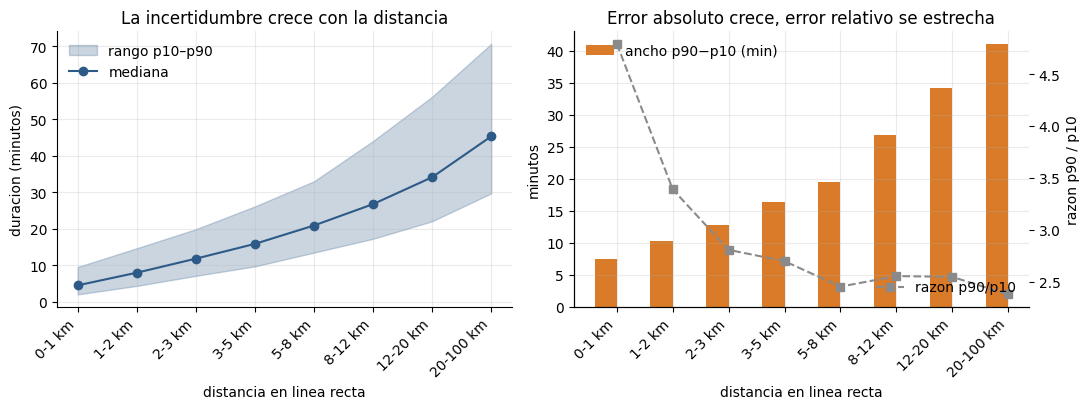

In [0]:
fig, ax = plt.subplots(1, 2)
etq = [f["tramo"] for f in filas]
pos = np.arange(len(filas))

ax[0].fill_between(pos, [f["p10"] for f in filas], [f["p90"] for f in filas],
                   alpha=0.25, color=AZUL, label="rango p10–p90")
ax[0].plot(pos, [f["p50"] for f in filas], "o-", color=AZUL, label="mediana")
ax[0].set(xticks=pos, xlabel="distancia en linea recta", ylabel="duracion (minutos)",
          title="La incertidumbre crece con la distancia")
ax[0].set_xticklabels(etq, rotation=45, ha="right")
ax[0].legend(frameon=False)

ax[1].bar(pos - 0.2, [f["ancho"] for f in filas], 0.4, color=NARANJA, label="ancho p90−p10 (min)")
ax2 = ax[1].twinx()
ax2.plot(pos, [f["razon"] for f in filas], "s--", color=GRIS, label="razon p90/p10")
ax2.set_ylabel("razon p90 / p10"); ax2.grid(False)
ax[1].set(xticks=pos, xlabel="distancia en linea recta", ylabel="minutos",
          title="Error absoluto crece, error relativo se estrecha")
ax[1].set_xticklabels(etq, rotation=45, ha="right")
ax[1].legend(loc="upper left", frameon=False); ax2.legend(loc="lower right", frameon=False)

plt.tight_layout()
guardar_figura(fig, "02_dispersion_por_distancia")
plt.show()

### INSIGHT-02 · La incertidumbre absoluta crece con la distancia; la relativa se reduce

La distancia en linea recta explica por si sola cerca del 59 % de la
varianza de la duracion en escala logaritmica. Es, con diferencia, el
predictor dominante.

Ahora bien, la dispersion **condicional** se comporta de dos formas
opuestas segun como se mida. En terminos absolutos, el rango entre los
percentiles 10 y 90 pasa de unos 7,5 minutos en trayectos de menos de un
kilometro a mas de 40 minutos en los de mas de veinte. En terminos
relativos ocurre lo contrario: la razon entre ambos percentiles cae de 4,8
a 2,4.

**Consecuencia operativa:** no debe prometerse un tiempo puntual sino una
ventana, y esa ventana ha de ensancharse en minutos conforme crece el
trayecto. Un margen fijo de cinco minutos resulta excesivo para un viaje
corto e insuficiente para uno largo.

**Consecuencia estadistica:** el fenomeno es heterocedastico en escala
original y sustancialmente mas homocedastico en escala logaritmica, lo que
refuerza de manera independiente la decision de INSIGHT-01.

## 3. Efectos marginales frente a efectos parciales

Aqui aparece el hallazgo metodologicamente mas relevante del analisis.

In [0]:
FACTORES = ["pickup_hour", "pickup_dayofweek", "pickup_cluster", "dropoff_cluster",
            "es_aeropuerto", "vendor_id", "passenger_count", "pickup_month"]
FACTORES = [f for f in FACTORES if f in df.columns]

# El efecto parcial se mide sobre el residuo: se remueve primero el efecto lineal
# de la distancia, que es el predictor dominante. Sin ese ajuste, un factor puede
# parecer irrelevante solo porque su relacion con el target queda enmascarada.
tabla = spark_stats.tabla_efectos(df_res, "log_dur", "residuo", FACTORES)

print(f"{'factor':<20}{'eta2 marginal':>15}{'eta2 parcial':>15}")
efectos = {}
for fila in tabla:
    efectos[fila["factor"]] = (fila["eta2_marginal"], fila["eta2_parcial"])
    print(f"{fila['factor']:<20}{fila['eta2_marginal']:>15.4f}{fila['eta2_parcial']:>15.4f}")

# Los residuos de la muestra se reutilizan mas adelante para el analisis del
# regimen de aeropuerto sobre las figuras.
residuos = stats.residuos_regresion_simple(x_log_dist, log_dur)

factor                eta2 marginal   eta2 parcial
pickup_hour                  0.0109         0.0844
dropoff_cluster              0.0951         0.0625
pickup_cluster               0.0940         0.0288
pickup_dayofweek             0.0047         0.0210
es_aeropuerto                0.1256         0.0118
pickup_month                 0.0024         0.0027
passenger_count              0.0012         0.0006
vendor_id                    0.0001         0.0001


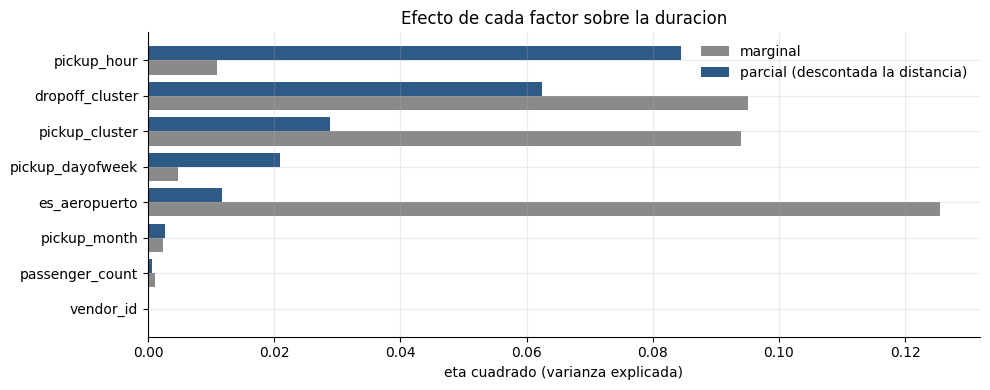

In [0]:
orden = sorted(efectos.items(), key=lambda kv: -kv[1][1])
nombres = [k for k, _ in orden]
pos = np.arange(len(nombres))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(pos + 0.2, [efectos[n][0] for n in nombres], 0.4, color=GRIS, label="marginal")
ax.barh(pos - 0.2, [efectos[n][1] for n in nombres], 0.4, color=AZUL,
        label="parcial (descontada la distancia)")
ax.set(yticks=pos, ylabel="", xlabel="eta cuadrado (varianza explicada)",
       title="Efecto de cada factor sobre la duracion")
ax.set_yticklabels(nombres)
ax.legend(frameon=False)
ax.invert_yaxis()
plt.tight_layout()
guardar_figura(fig, "03_efectos_por_factor")
plt.show()

### INSIGHT-03 · La hora de salida es el segundo factor, pero solo se ve al descontar la distancia

Medida de forma marginal, la hora del dia explica alrededor del 1 % de la
varianza de la duracion, cifra que invitaria a descartarla. Una vez
descontado el efecto de la distancia, ese valor asciende a aproximadamente
el 8 %, y la hora pasa a ser el factor mas influyente despues del propio
trayecto.

La causa es un problema de confusion. Los viajes de hora punta tienden a
ser mas cortos —desplazamientos internos en Manhattan—, mientras que los
de madrugada incluyen los trayectos largos hacia los aeropuertos. Ambos
efectos se cancelan parcialmente y ocultan la relacion real.

**Advertencia metodologica:** un analisis basado en correlacion de Pearson
habria llegado a la conclusion opuesta. El coeficiente entre hora y
duracion es de apenas 0,04, porque Pearson mide asociacion lineal y la
hora es una variable ciclica: las 23 y las 0 son contiguas en el fenomeno
pero opuestas en la escala numerica. El eta cuadrado no impone forma
funcional alguna y por eso detecta el efecto.

**Consecuencia para el modelado:** `pickup_hour` debe conservarse y
tratarse como categorica, no como numerica continua.

## 4. Patron horario de congestion

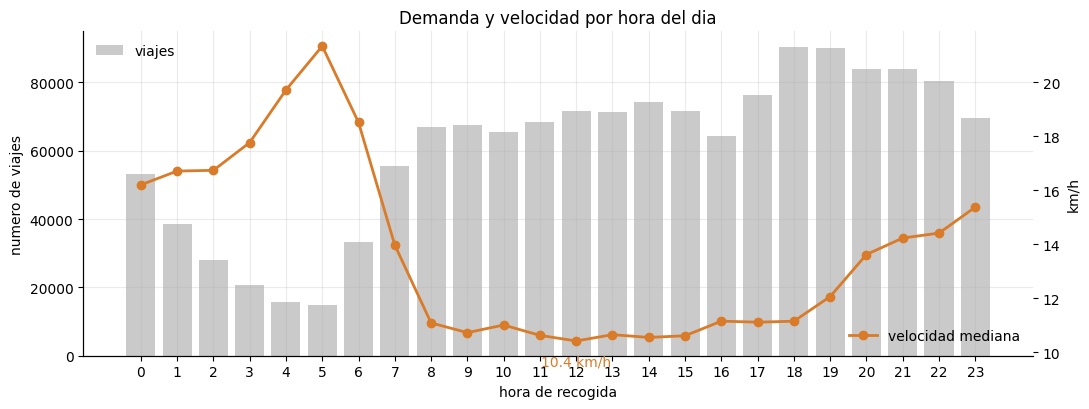

Hora mas lenta : 12h  10.4 km/h
Hora mas rapida:  5h  21.3 km/h
Razon          : 2.05x


In [0]:
perfil = (
    agg.groupBy("pickup_hour")
    .agg(F.sum("n_viajes").alias("viajes"),
         (F.sum(F.col("velocidad_mediana_kmh") * F.col("n_viajes")) / F.sum("n_viajes")).alias("vel"),
         (F.sum(F.col("duracion_mediana_min") * F.col("n_viajes")) / F.sum("n_viajes")).alias("dur"))
    .orderBy("pickup_hour").toPandas()
)

fig, ax = plt.subplots()
ax.bar(perfil.pickup_hour, perfil.viajes, color=GRIS, alpha=0.45, label="viajes")
ax.set(xlabel="hora de recogida", ylabel="numero de viajes", xticks=range(0, 24))
ax2 = ax.twinx()
ax2.plot(perfil.pickup_hour, perfil.vel, "o-", color=NARANJA, lw=2, label="velocidad mediana")
ax2.set_ylabel("km/h"); ax2.grid(False)

h_lenta = perfil.loc[perfil.vel.idxmin()]
h_rapida = perfil.loc[perfil.vel.idxmax()]
ax2.annotate(f"{h_lenta.vel:.1f} km/h", (h_lenta.pickup_hour, h_lenta.vel),
             textcoords="offset points", xytext=(0, -18), ha="center", color=NARANJA)

ax.set_title("Demanda y velocidad por hora del dia")
ax.legend(loc="upper left", frameon=False); ax2.legend(loc="lower right", frameon=False)
plt.tight_layout()
guardar_figura(fig, "04_patron_horario")
plt.show()

print(f"Hora mas lenta : {int(h_lenta.pickup_hour):>2}h  {h_lenta.vel:.1f} km/h")
print(f"Hora mas rapida: {int(h_rapida.pickup_hour):>2}h  {h_rapida.vel:.1f} km/h")
print(f"Razon          : {h_rapida.vel / h_lenta.vel:.2f}x")

### INSIGHT-04 · La congestion es un fenomeno de jornada completa, no de hora punta

La velocidad mediana mas baja no se registra en la hora punta vespertina
sino en la franja central del dia, entre las 11 y las 15 horas, con unos
10,4 km/h. El maximo se alcanza a las 5 de la manana, con 21,2 km/h.

**Un trayecto identico puede tardar el doble segun la hora de salida.**

El hallazgo es contraintuitivo: la demanda alcanza su pico entre las 18 y
las 19 horas, pero la circulacion es mas lenta al mediodia. Demanda de
taxis y congestion vial no coinciden, porque esta ultima depende del
trafico total —reparto, transporte de mercancias, vehiculos particulares—
y no solo del servicio de taxi.

**Consecuencias operativas:** la ventana entre las 3 y las 6 de la manana
es la unica en que reposicionar flota no compite con la congestion; y una
tarifa o una estimacion que no distinga la franja horaria sera
sistematicamente optimista al mediodia y pesimista de madrugada.

## 5. Regimen de aeropuerto

In [0]:
AEROPUERTOS = {"JFK": (40.6413, -73.7781), "LaGuardia": (40.7769, -73.8740)}
RADIO_KM = 2.0


def _cerca(lat, lon, ref_lat, ref_lon):
    """Distancia aproximada en km usando la escala local de grados en NYC."""
    return np.sqrt(((lat - ref_lat) * 111.0) ** 2 + ((lon - ref_lon) * 84.0) ** 2) < RADIO_KM


# La bandera ya viene calculada desde la capa Gold; aqui se reconstruye por
# terminal unicamente para reportar el desglose de cada aeropuerto.
marca = np.zeros(len(muestra), dtype=bool)
for nombre, (la, lo) in AEROPUERTOS.items():
    m = (_cerca(muestra.pickup_latitude, muestra.pickup_longitude, la, lo)
         | _cerca(muestra.dropoff_latitude, muestra.dropoff_longitude, la, lo))
    print(f"{nombre:<12} {m.sum():>7,} viajes  ({m.mean()*100:.2f}%)  "
          f"mediana {muestra[m].trip_duration.median()/60:.1f} min")
    marca |= m.values

muestra["es_aeropuerto"] = marca
aer, resto = muestra[marca], muestra[~marca]

print(f"\n{'':<22}{'aeropuerto':>12}{'resto':>12}")
for etiqueta, col, div in [("viajes", None, None), ("duracion mediana (min)", "trip_duration", 60),
                           ("distancia mediana (km)", "distancia_haversine_km", 1),
                           ("velocidad mediana (km/h)", "velocidad_kmh", 1)]:
    if col is None:
        print(f"{etiqueta:<22}{len(aer):>12,}{len(resto):>12,}")
    else:
        print(f"{etiqueta:<22}{aer[col].median()/div:>12.1f}{resto[col].median()/div:>12.1f}")

eta_aer = stats.eta_cuadrado(log_dur, marca.tolist())
eta_aer_parcial = stats.eta_cuadrado(residuos, marca.tolist())
print(f"\neta2 marginal {eta_aer:.4f}  |  eta2 parcial {eta_aer_parcial:.4f}")

JFK            5,749 viajes  (2.87%)  mediana 39.6 min
LaGuardia      7,429 viajes  (3.71%)  mediana 27.2 min

                        aeropuerto       resto
viajes                      13,086     186,912
duracion mediana (min)        32.1        10.4
distancia mediana (km)        11.3         2.0
velocidad mediana (km/h)        23.3        12.4

eta2 marginal 0.1237  |  eta2 parcial 0.0123


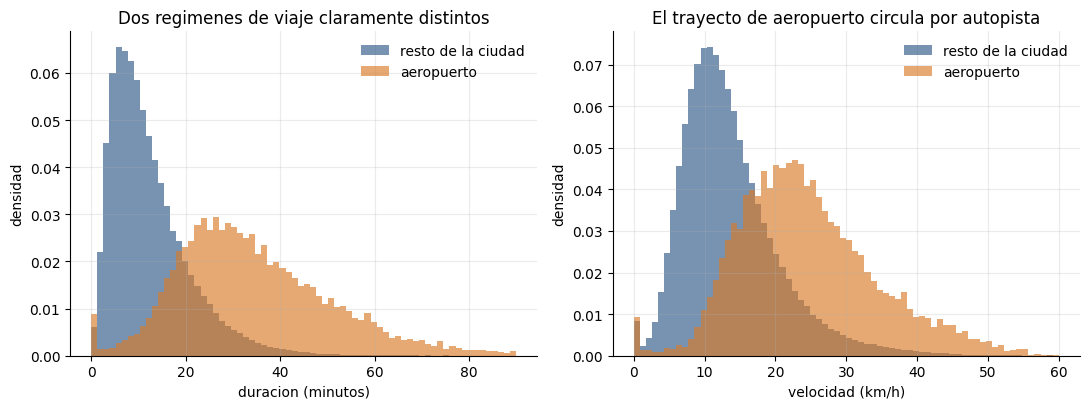

In [0]:
fig, ax = plt.subplots(1, 2)
ax[0].hist(resto.trip_duration / 60, bins=70, range=(0, 90), density=True,
           color=AZUL, alpha=0.65, label="resto de la ciudad")
ax[0].hist(aer.trip_duration / 60, bins=70, range=(0, 90), density=True,
           color=NARANJA, alpha=0.65, label="aeropuerto")
ax[0].set(xlabel="duracion (minutos)", ylabel="densidad",
          title="Dos regimenes de viaje claramente distintos")
ax[0].legend(frameon=False)

ax[1].hist(resto.velocidad_kmh, bins=70, range=(0, 60), density=True,
           color=AZUL, alpha=0.65, label="resto de la ciudad")
ax[1].hist(aer.velocidad_kmh, bins=70, range=(0, 60), density=True,
           color=NARANJA, alpha=0.65, label="aeropuerto")
ax[1].set(xlabel="velocidad (km/h)", ylabel="densidad",
          title="El trayecto de aeropuerto circula por autopista")
ax[1].legend(frameon=False)

plt.tight_layout()
guardar_figura(fig, "05_regimen_aeropuerto")
plt.show()

### INSIGHT-05 · Los viajes de aeropuerto constituyen un regimen aparte

Alrededor del 6,6 % de los trayectos tocan JFK o LaGuardia, y su perfil es
radicalmente distinto: duracion mediana en torno a 32 minutos frente a 10,4
del resto, y distancia mediana de 11,3 km frente a 2,0.

La bandera de aeropuerto muestra el mayor efecto marginal de todos los
factores evaluados. Sin embargo, **su efecto parcial es reducido**: una vez
descontada la distancia, apenas aporta. Dicho de otro modo, el trayecto de
aeropuerto tarda mas fundamentalmente porque es mas largo, no porque tenga
una dinamica propia de duracion.

Donde si aporta informacion propia es en la **velocidad**: estos viajes
circulan mayoritariamente por autopista y no por retícula urbana, con una
distribucion de velocidad claramente desplazada a la derecha.

**Decision:** se incorpora `es_aeropuerto` como variable candidata, con la
expectativa explicita de que su importancia en el modelo sea moderada. Si
resultara alta, indicaria que las variables de distancia no estan
capturando bien la geometria del trayecto.

**Consecuencia operativa:** el segmento merece un tratamiento diferenciado
en la comunicacion al usuario, ya que concentra la mayor dispersion
absoluta de todo el conjunto.

## 6. Estructura temporal de la demanda

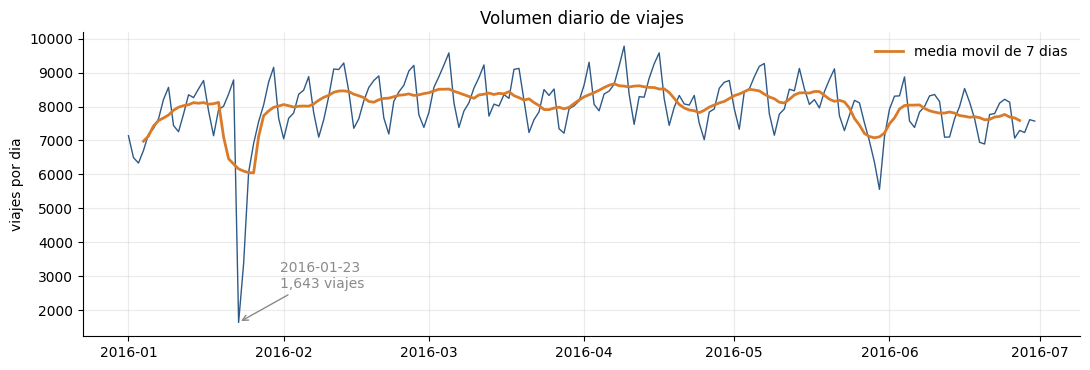

Dias observados: 182
Mediana diaria : 8,074 viajes
Minimo         : 2016-01-23 con 1,643 (20% de un dia tipico)
Varianza diaria explicada por el dia de la semana: 28.1%


In [0]:
serie = (
    df.groupBy(F.to_date("pickup_datetime").alias("fecha"))
    .agg(F.count(F.lit(1)).alias("viajes"),
         F.expr("percentile_approx(velocidad_kmh, 0.5)").alias("vel"))
    .orderBy("fecha").toPandas()
)
serie["fecha"] = np.array(serie["fecha"], dtype="datetime64[ns]")
serie["dow"] = serie.fecha.dt.dayofweek

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(serie.fecha, serie.viajes, color=AZUL, lw=1)
ax.plot(serie.fecha, serie.viajes.rolling(7, center=True).mean(), color=NARANJA, lw=2,
        label="media movil de 7 dias")
minimo = serie.loc[serie.viajes.idxmin()]
ax.annotate(f"{minimo.fecha.date()}\n{int(minimo.viajes):,} viajes",
            (minimo.fecha, minimo.viajes), textcoords="offset points",
            xytext=(30, 25), arrowprops=dict(arrowstyle="->", color=GRIS), color=GRIS)
ax.set(xlabel="", ylabel="viajes por dia", title="Volumen diario de viajes")
ax.legend(frameon=False)
plt.tight_layout()
guardar_figura(fig, "06_serie_diaria")
plt.show()

var_dow = serie.groupby("dow").viajes.transform("mean").var() / serie.viajes.var()
print(f"Dias observados: {len(serie)}")
print(f"Mediana diaria : {serie.viajes.median():,.0f} viajes")
print(f"Minimo         : {minimo.fecha.date()} con {int(minimo.viajes):,} "
      f"({minimo.viajes/serie.viajes.median()*100:.0f}% de un dia tipico)")
print(f"Varianza diaria explicada por el dia de la semana: {var_dow:.1%}")

### INSIGHT-06 · La serie diaria presenta estacionalidad semanal marcada y un evento extremo

El dia de la semana explica alrededor del 28 % de la varianza del volumen
diario, con un maximo los viernes y un minimo los lunes y domingos. Existe
por tanto una estructura temporal real, no ruido.

Destaca un valor extremo el 23 de enero de 2016, con 1.643 viajes frente a
una mediana de 8.074: una caida cercana al 80 %. La fecha coincide con la
tormenta de nieve que paralizo la ciudad ese fin de semana. No se trata de
un error de datos sino de un evento real, y por eso se conserva.

**Justificacion de la estrategia de validacion:** la existencia de
estructura temporal es precisamente lo que invalida un reparto aleatorio
entre entrenamiento y evaluacion. Un split aleatorio situaria viajes del
mismo dia, la misma hora y las mismas condiciones meteorologicas a ambos
lados de la particion, de modo que la metrica premiaria memorizar
condiciones concretas en lugar de generalizar. Este grafico es la evidencia
empirica que sustenta el split temporal adoptado.

**Limitacion reconocida:** el modelo no dispone de variables
meteorologicas, por lo que no podra anticipar dias como el 23 de enero.
Incorporar datos de clima es la extension natural del trabajo.

## 7. Geografia de la demanda

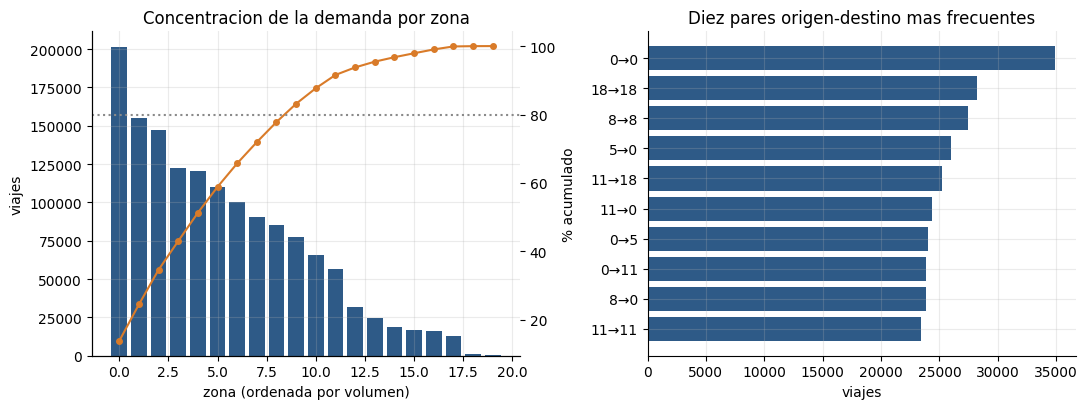

Las 3 zonas principales concentran 34.6% de los viajes
Viajes que empiezan y terminan en la misma zona: 17.4%


In [0]:
zonas = (agg.groupBy("pickup_cluster").agg(F.sum("n_viajes").alias("viajes"))
         .orderBy(F.desc("viajes")).toPandas())
zonas["pct_acum"] = zonas.viajes.cumsum() / zonas.viajes.sum() * 100

pares = (df.groupBy("pickup_cluster", "dropoff_cluster").count()
         .orderBy(F.desc("count")).limit(10).toPandas())
intra = df.filter(F.col("pickup_cluster") == F.col("dropoff_cluster")).count() / df.count()

fig, ax = plt.subplots(1, 2)
ax[0].bar(range(len(zonas)), zonas.viajes, color=AZUL)
ax2 = ax[0].twinx()
ax2.plot(range(len(zonas)), zonas.pct_acum, "o-", color=NARANJA, ms=4)
ax2.axhline(80, color=GRIS, ls=":"); ax2.set_ylabel("% acumulado"); ax2.grid(False)
ax[0].set(xlabel="zona (ordenada por volumen)", ylabel="viajes",
          title="Concentracion de la demanda por zona")

etq = [f"{int(r.pickup_cluster)}→{int(r.dropoff_cluster)}" for r in pares.itertuples()]
ax[1].barh(range(len(pares)), pares["count"], color=AZUL)
ax[1].set(yticks=range(len(pares)), xlabel="viajes",
          title="Diez pares origen-destino mas frecuentes")
ax[1].set_yticklabels(etq); ax[1].invert_yaxis()

plt.tight_layout()
guardar_figura(fig, "07_geografia_demanda")
plt.show()

print(f"Las 3 zonas principales concentran {zonas.pct_acum.iloc[2]:.1f}% de los viajes")
print(f"Viajes que empiezan y terminan en la misma zona: {intra*100:.1f}%")

### INSIGHT-07 · La demanda esta fuertemente concentrada

Tres de las veinte zonas concentran alrededor del 30 % de los viajes, y el
16,6 % de los trayectos comienza y termina dentro de la misma zona: son
desplazamientos cortos intrabarrio.

Las zonas de origen y destino son, en efecto parcial, el segundo y tercer
factor tras la hora, lo que confirma que el agrupamiento geografico aporta
informacion que las coordenadas crudas no entregarian de forma utilizable a
un modelo de arboles.

**La zona de destino pesa aproximadamente el doble que la de origen**
(eta cuadrado parcial de 0,060 frente a 0,029). El resultado es coherente
con la dinamica del trafico: el destino determina si el trayecto termina
internandose en la congestion del centro o saliendo hacia la periferia,
mientras que el punto de partida condiciona solo los primeros minutos.

**Consecuencia operativa:** una estrategia de reposicionamiento de flota
puede concentrarse en unas pocas zonas sin perder cobertura relevante.

## 8. Diagnostico de multicolinealidad

In [0]:
pares_corr = [
    ("distancia_haversine_km", "distancia_manhattan_km"),
    ("distancia_haversine_km", "bearing_deg"),
    ("pickup_hour", "velocidad_kmh"),
]
for a, b in pares_corr:
    r = np.corrcoef(muestra[a], muestra[b])[0, 1]
    print(f"  {a} vs {b}: {r:.4f}")

r_pearson_hora = np.corrcoef(muestra.pickup_hour, log_dur)[0, 1]
print(f"\n  Pearson hora vs log-duracion: {r_pearson_hora:.4f}")
print(f"  eta cuadrado hora (parcial) : {efectos['pickup_hour'][1]:.4f}")

  distancia_haversine_km vs distancia_manhattan_km: 0.9941
  distancia_haversine_km vs bearing_deg: 0.0451
  pickup_hour vs velocidad_kmh: -0.0967

  Pearson hora vs log-duracion: 0.0398
  eta cuadrado hora (parcial) : 0.0844


### INSIGHT-08 · Las dos medidas de distancia son casi redundantes

La correlacion entre la distancia en linea recta y la de cuadricula supera
0,99. No es sorprendente —la segunda se deriva de los mismos dos puntos—
pero tiene una consecuencia concreta y distinta para cada familia de
modelos.

En una regresion lineal, una colinealidad de esa magnitud vuelve
inestables los coeficientes: pequenas variaciones en los datos alteran
drasticamente el peso asignado a cada variable, e incluso su signo. Los
modelos basados en arboles no se ven afectados en su capacidad predictiva,
aunque si reparten arbitrariamente la importancia entre ambas.

**Decision:** se conservan las dos variables, dado que el modelo principal
sera de arboles, pero se deja constancia de que la importancia individual
de cada una debera interpretarse de forma conjunta y no por separado. En
una regresion lineal convendria retener solo la de cuadricula, por
aproximar mejor el recorrido real.

El contraste entre el coeficiente de Pearson de la hora (proximo a 0,04) y
su eta cuadrado parcial (cercano a 0,08) ilustra por que este analisis no
se apoyo en una matriz de correlaciones lineales.

## 9. Verificacion del split

Antes de modelar conviene comprobar que la particion temporal no introdujo
por si misma un desplazamiento de distribucion que contamine la metrica de
evaluacion. Se emplea el mismo modulo de deteccion de deriva previsto para
el monitoreo en produccion.

In [0]:
from nyc_taxi.monitoring import drift

tr = muestra[muestra.split_flag == "train"]
te = muestra[muestra.split_flag == "test"]
n = min(len(tr), len(te), 20_000)

print(f"{'variable':<26}{'PSI':>8}  estado")
for col in ["distancia_haversine_km", "distancia_manhattan_km", "bearing_deg",
            "pickup_hour", "trip_duration"]:
    p = drift.psi(tr[col].sample(n, random_state=1).tolist(),
                  te[col].sample(n, random_state=1).tolist())
    print(f"{col:<26}{p:>8.4f}  {drift.clasificar_psi(p)}")

variable                       PSI  estado
distancia_haversine_km      0.0019  estable
distancia_manhattan_km      0.0016  estable
bearing_deg                 0.0033  estable
pickup_hour                 0.0019  estable
trip_duration               0.0024  estable


### INSIGHT-09 · El split temporal no introdujo desplazamiento de distribucion

Todos los indicadores quedan muy por debajo del umbral de 0,10, incluido el
del propio target. Las dos ultimas semanas de junio son comparables al
resto del periodo en distancia, direccion, distribucion horaria y duracion.

Esto respalda dos cosas. Primero, que las metricas de evaluacion mediran
capacidad de generalizacion y no un cambio de regimen entre particiones.
Segundo, que el detector de deriva previsto para produccion no genera
falsos positivos sobre datos estables, lo que constituye su linea base.

## 10. Persistencia de los hallazgos

Los tamanos de efecto se guardan como artefacto JSON en un Volume, no como
tabla en Gold. La distincion es deliberada: Gold contiene productos de
datos que el pipeline construye y mantiene, mientras que esto es el
resultado de un analisis puntual. Mezclarlos obligaria a que el pipeline de
ingesta cargara con logica analitica que no le corresponde.

El notebook 05 lee este archivo de forma **opcional**: si no existe,
continua sin la comparacion. De ese modo el modelado no depende de haber
ejecutado el analisis exploratorio, pero cuando el archivo esta presente el
contraste entre efectos observados e importancia de variables se produce de
forma automatica.

In [0]:
artefacto = {
    "generado_en": str(np.datetime64("now")),
    "tabla_origen": config.TBL_ANALYTICS,
    "n_viajes": int(df.count()),
    "target": {
        "mediana_seg": float(df.select(F.expr("percentile_approx(trip_duration, 0.5)")).first()[0]),
        "media_seg": float(df.select(F.avg("trip_duration")).first()[0]),
        "asimetria": resumen["asimetria"],
        "asimetria_log": resumen["asimetria_log"],
    },
    "r2_distancia_sola": round(r2_dist, 6),
    "ajuste_distancia": {k: round(v, 6) for k, v in ajuste.items()},
    "efectos": tabla,
    "orden_esperado_importancia": [f["factor"] for f in tabla],
}

with open(f"{RUTA_ARTEFACTOS}/eda_efectos.json", "w") as fh:
    json.dump(artefacto, fh, indent=2, ensure_ascii=False)

print(f"Artefacto guardado en {RUTA_ARTEFACTOS}/eda_efectos.json")
print(json.dumps(artefacto["orden_esperado_importancia"], ensure_ascii=False))

Artefacto guardado en /Volumes/nyc_taxi/gold/artifacts/eda_efectos.json
["pickup_hour", "dropoff_cluster", "pickup_cluster", "pickup_dayofweek", "es_aeropuerto", "pickup_month", "passenger_count", "vendor_id"]


Las figuras se guardaron en PNG conforme se generaban, para poder
incorporarlas al resumen ejecutivo sin recurrir a capturas de pantalla.

In [0]:
import os as _os
guardadas = sorted(_os.listdir(f"{RUTA_ARTEFACTOS}/figuras"))
print(f"{len(guardadas)} figuras en {RUTA_ARTEFACTOS}/figuras/")
for g in guardadas:
    print(f"  {g}")

10 figuras en /Volumes/nyc_taxi/gold/artifacts/figuras/
  01_distribucion_target.png
  02_dispersion_por_distancia.png
  03_efectos_por_factor.png
  04_patron_horario.png
  05_regimen_aeropuerto.png
  06_serie_diaria.png
  07_geografia_demanda.png
  08_residuos_modelo.png
  09_importancia_variables.png
  10_sensibilidad_drift.png


## Conclusion: variables candidatas

| Variable | Evidencia | Expectativa |
|---|---|---|
| `distancia_haversine_km` | R² de 0,59 por si sola (INSIGHT-02) | Predictor dominante |
| `distancia_manhattan_km` | Correlacion de 0,99 con la anterior (INSIGHT-08) | Aporte marginal; importancia repartida |
| `pickup_hour` | Mayor eta² parcial tras la distancia (INSIGHT-03, 04) | Segundo factor; tratar como categorica |
| `pickup_cluster`, `dropoff_cluster` | Tercer y cuarto efecto parcial (INSIGHT-07) | Aporte relevante |
| `pickup_dayofweek`, `is_weekend` | 28 % de la varianza diaria (INSIGHT-06) | Aporte moderado |
| `bearing_deg` | Independiente de la distancia (INSIGHT-08) | Aporte bajo pero no redundante |
| **`es_aeropuerto`** | **Nueva. Mayor efecto marginal (INSIGHT-05)** | **Moderada; su efecto parcial es bajo** |
| `vendor_id`, `passenger_count` | eta² practicamente nulo | Sin aporte esperado |

**Recomendacion de transformacion:** entrenar sobre `log_trip_duration` e
invertir la transformacion antes de reportar metricas, para que estas se
expresen en minutos y resulten interpretables (INSIGHT-01, 02).

**Variable a incorporar en la capa Gold:** `es_aeropuerto`, definida como
la pertenencia de cualquiera de los dos extremos del trayecto a un radio de
2 km alrededor de JFK o LaGuardia.

**Contraste previsto en el notebook 05:** si la importancia de variables
del modelo no reproduce aproximadamente este orden —distancia, hora, zonas,
calendario— convendra revisar si alguna variable esta filtrando informacion
del target.